# Forecast vs. Actual - export shipment adherence

How well did each export market's **forecast** match what was actually **loaded**? This notebook ingests three messy source files, applies the business rules, and measures forecast accuracy per market and per month.

*Anonymized portfolio project - fictional markets and figures, reproducible synthetic data.*

## 1. Setup
Make the `src` package importable and work from the project root so the `data/` and `output/` paths resolve whether you run this from the repo root or from `notebooks/`.

In [1]:
import os, sys
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
import pandas as pd
from IPython.display import Image
from src import sample_data, ingest, transform, analysis, report
pd.set_option('display.max_rows', 15)

## 2. The raw sources
Three Excel files with different layouts: an early-months workbook (one sheet per month, values offset under title rows), later months as separate files (header on row 5, a dynamically named month column), and a per-vehicle loading log with **hand-typed market names** (aliases, typos, hub members under their own name).

In [2]:
data_dir = sample_data.generate_all('data')
forecast_long = ingest.read_all_forecast(data_dir)
loading_long = ingest.read_loading_log(data_dir / 'loading_log.xlsx')
print('forecast rows:', len(forecast_long), '| loading rows:', len(loading_long))
loading_long.head(8)  # note the messy, hand-typed market names

forecast rows: 108 | loading rows: 564


,month,market_raw,vehicles,Date
0,March,Stela,1,2026-03-14
1,March,Avalon Port,1,2026-03-25
2,April,Stela,3,2026-04-12
3,May,Torin & Co,1,2026-05-18
4,May,Bramor,2,2026-05-08
5,February,Bramor City,1,2026-02-03
6,February,Bramor City,1,2026-02-11
7,May,Torin,1,2026-05-20


## 3. Business rules
Normalise market names to codes, drop road-freight lanes (sea only), consolidate the low-volume hub members into a single `HUB` lane, and convert forecast pallets to containers (pallets / 22) so they compare with the real vehicle count. The result is one tidy comparison table.

In [3]:
forecast_df = transform.prepare_forecast(forecast_long)
loading_df = transform.prepare_loading(loading_long)
comp = transform.build_comparison(forecast_df, loading_df)
comp.head(12)

,month,market,forecast_pallets,forecast_containers,real_vehicles,difference,bid
0,January,AVL,683,31.045455,41,9.954545,25
1,January,BRG,523,23.772727,20,-3.772727,20
2,January,CDR,456,20.727273,23,2.272727,15
3,January,DLT,275,12.500000,11,-1.500000,10
4,January,ELM,179,8.136364,6,-2.136364,8
5,January,FRN,152,6.909091,8,1.090909,6
6,January,GLD,89,4.045455,4,-0.045455,4
7,January,HUB,491,22.318182,21,-1.318182,20
8,January,JZR,48,2.181818,1,-1.181818,2
9,January,TRN,302,13.727273,19,5.272727,12


## 4. Accuracy KPIs
**Bias** = systematic over/under-planning. **MAPE** = typical error size. **Hit rate** = share of lanes within +/-20% of forecast.

In [4]:
analysis.monthly_kpis(comp)

,month,forecast_containers,real_vehicles,bias,bias_pct,mape_pct,hit_rate_pct,lanes
0,January,145.4,154,8.6,5.9,21.3,60.0,10
1,February,121.8,138,16.2,13.3,23.9,60.0,10
2,March,123.2,134,10.8,8.7,22.6,50.0,10
3,April,124.7,123,-1.7,-1.3,17.3,60.0,10
4,May,119.6,133,13.4,11.2,17.6,70.0,10
5,June,123.0,134,11.0,8.9,21.5,70.0,10


In [5]:
analysis.overall_kpis(comp)

{'forecast_containers': np.float64(757.6),
 'real_vehicles': 816,
 'bias': np.float64(58.4),
 'bias_pct': np.float64(7.7),
 'mape_pct': np.float64(20.7),
 'hit_rate_pct': np.float64(61.7),
 'lanes': 10,
 'months': 6}

## 5. Visuals
Forecast vs. actual per market, with the target line - and the accuracy trend across months.

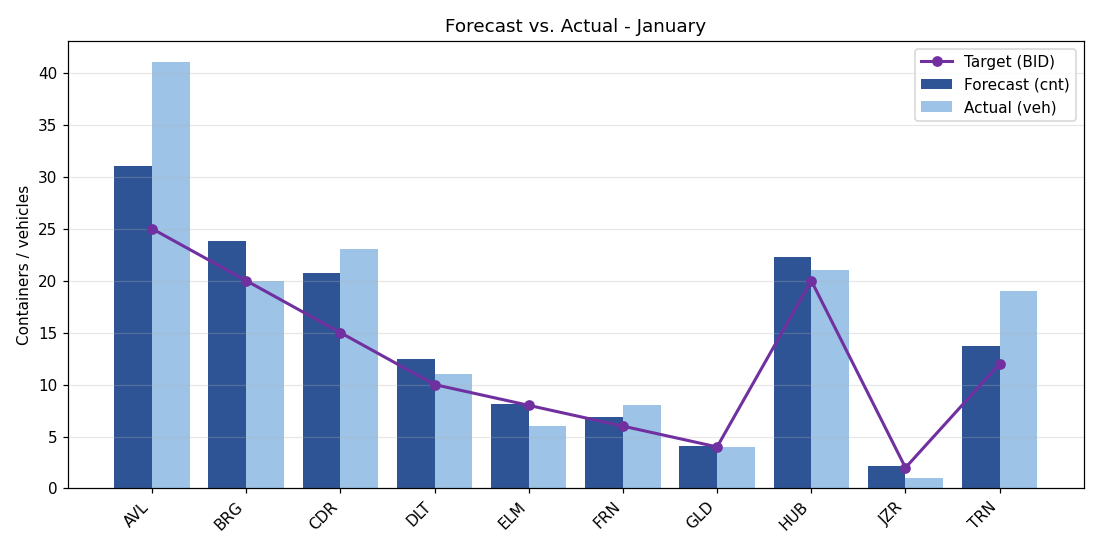

In [6]:
charts = report.save_charts(comp, 'output/charts')
Image('output/charts/comparison_january.png')

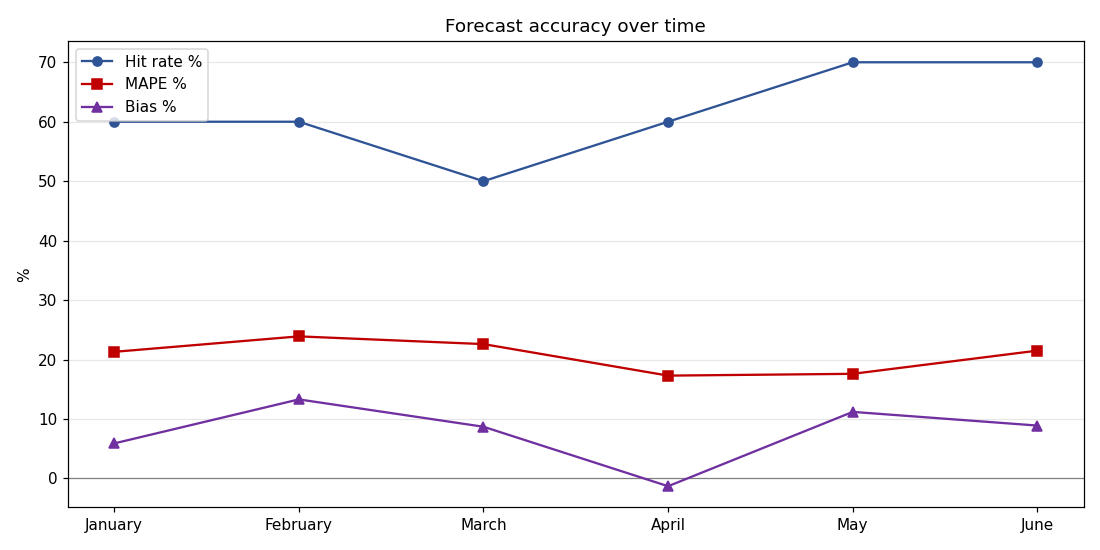

In [7]:
Image('output/charts/accuracy_trend.png')

## 6. Where the plan missed most
The largest gaps tell planners which lanes to revisit - and which markets are structurally hard to forecast.

In [8]:
analysis.top_deviations(comp, 8)

,month,market,forecast_containers,real_vehicles,difference,ape_pct,direction
0,June,AVL,31.1,47,15.9,51.2,over
1,February,AVL,25.1,38,12.9,51.2,over
2,January,AVL,31.0,41,10.0,32.1,over
3,March,AVL,29.1,38,8.9,30.4,over
4,March,TRN,16.5,25,8.5,51.5,over
5,May,TRN,14.7,23,8.3,56.7,over
6,May,AVL,19.4,27,7.6,39.4,over
7,April,AVL,27.7,34,6.3,22.6,over


In [9]:
analysis.market_accuracy(comp)

,market,forecast_containers,real_vehicles,mape_pct,hit_rate_pct,bias
0,TRN,75.090909,106,39.5,16.7,30.9
1,AVL,163.500000,225,37.8,0.0,61.5
2,ELM,51.227273,33,36.2,0.0,-18.2
3,JZR,12.454545,8,36.1,16.7,-4.5
4,BRG,108.818182,98,15.3,83.3,-10.8
5,DLT,64.090909,59,11.2,100.0,-5.1
6,FRN,37.454545,40,11.0,100.0,2.5
7,CDR,94.136364,95,8.5,100.0,0.9
8,GLD,25.000000,25,6.4,100.0,0.0
9,HUB,125.863636,127,4.8,100.0,1.1


## 7. Deliverable
The same analysis is exported as the formatted Excel workbook operators use (one comparison sheet per month, combo charts, a KPI summary).

In [10]:
path = report.write_excel(comp, 'output/forecast_vs_actual.xlsx')
print('Wrote', path)

Wrote output\forecast_vs_actual.xlsx
